<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Output/plots/Spats/Spat_Physiology/Spat_Resp/Respiration_Rate_for_spats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Respiration_Rate for spats in ambiant

--- Ambient Samples Removed (OxyRate > 2.09) ---
Morph: NF, SampleCode: plateD_NF_8.2_7, OxyRate: 5.27
Morph: NF, SampleCode: plateD_NF_8.2_7, OxyRate: 4.21
Morph: NF, SampleCode: plateD_NF_8.2_3, OxyRate: 3.01
Morph: PF, SampleCode: med_Flu_polyp, OxyRate: 2.87
Morph: NF, SampleCode: plateD_NF_8.2_2, OxyRate: 2.62
Morph: NF, SampleCode: plateD_NF_8.2_3, OxyRate: 2.41
Morph: NF, SampleCode: plateD_NF_8.2_2, OxyRate: 2.10
---------------------------------------------------

=== One-Way ANOVA Results ===


,Statistic,Value
0,F-statistic,5.359063
1,P-value,0.005576



=== Tukey's HSD Post-hoc Test Results ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    HF     NF  -0.2115 0.0264  -0.403 -0.0201   True
    HF     PF  -0.2445 0.0204 -0.4581 -0.0308   True
    NF     PF  -0.0329  0.942 -0.2695  0.2037  False
----------------------------------------------------


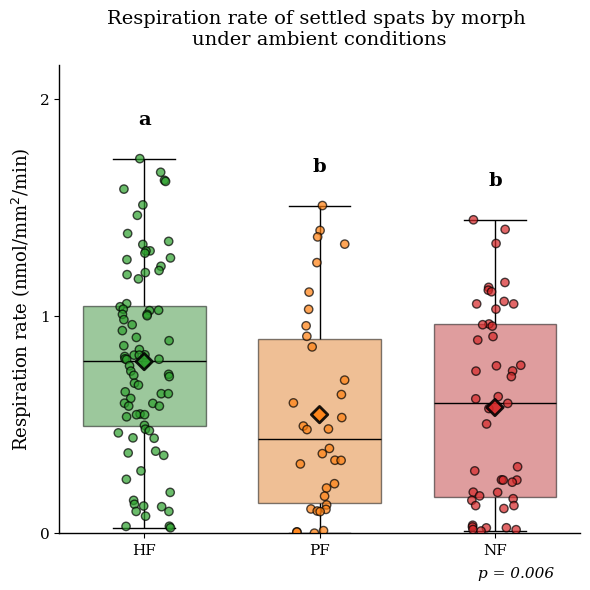

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import matplotlib.ticker as ticker
from statsmodels.stats.multicomp import pairwise_tukeyhsd # Import for Tukey's HSD

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = 'Ambient_Assay.csv'
df_resp = pd.read_csv(filename)

# Filter for the relevant morphs (just in case)
target_morphs = ['HF', 'PF', 'NF']
df_resp = df_resp[df_resp['morph'].isin(target_morphs)]

# --- NEW: Filter samples above 2.09 and print removed samples ---
removed_ambient_samples = df_resp[df_resp['OxyRate nmol/mm2/min'] > 2.09]
if not removed_ambient_samples.empty:
    print("--- Ambient Samples Removed (OxyRate > 2.09) ---")
    for index, row in removed_ambient_samples.iterrows():
        print(f"Morph: {row['morph']}, SampleCode: {row['SampleCode']}, OxyRate: {row['OxyRate nmol/mm2/min']:.2f}")
    print("---------------------------------------------------")
df_resp = df_resp[df_resp['OxyRate nmol/mm2/min'] <= 2.09]
# ----------------------------------------------------------------

# ==========================================
# 2. STATISTICS (One-Way ANOVA)
# ==========================================
# We use ANOVA because we now have 3 groups (HF, PF, NF)
hf_vals = df_resp[df_resp['morph'] == 'HF']['OxyRate nmol/mm2/min']
pf_vals = df_resp[df_resp['morph'] == 'PF']['OxyRate nmol/mm2/min']
nf_vals = df_resp[df_resp['morph'] == 'NF']['OxyRate nmol/mm2/min']

f_stat, p_val_resp = stats.f_oneway(hf_vals, pf_vals, nf_vals)

# Present ANOVA results in a table
anova_table_data = {'Statistic': ['F-statistic', 'P-value'],
                    'Value': [f_stat, p_val_resp]}
anova_df = pd.DataFrame(anova_table_data)
print("\n=== One-Way ANOVA Results ===")
display(anova_df)

# --- NEW: Tukey's HSD Post-hoc Test ---
# Create a 'group' column for Tukey's HSD
df_resp['group'] = df_resp['morph']

tukey_result = pairwise_tukeyhsd(endog=df_resp['OxyRate nmol/mm2/min'], groups=df_resp['group'], alpha=0.05)

print("\n=== Tukey's HSD Post-hoc Test Results ===")
print(tukey_result)
# -------------------------------------------

# Letter assignment logic
# If p > 0.05, no difference (all 'a'). If p < 0.05, we would need post-hoc tests.
# For now, if non-significant, all get 'a'.
if p_val_resp < 0.05:
    # Based on Tukey's HSD: HF is different from NF and PF, but NF and PF are not different.
    letters_map = {'HF': 'a', 'PF': 'b', 'NF': 'b'}
else:
    letters_map = {'HF': 'a', 'PF': 'a', 'NF': 'a'}

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'axes.edgecolor': 'black', 'axes.linewidth': 1,
    'xtick.color': 'black', 'ytick.color': 'black',
    'text.color': 'black', 'axes.labelcolor': 'black',
    'legend.frameon': False,
    'ytick.labelsize': 11,
    'xtick.labelsize': 11
})

# Define Colors and Order
variant_colors = {'HF': '#2ca02c', 'PF': '#ff7f0e', 'NF': '#d62728'}
morph_order = ['HF', 'PF', 'NF']

plt.figure(figsize=(6, 6))

# ==========================================
# 4. PLOT CONSTRUCTION
# ==========================================

# A. Box Plot
ax = sns.boxplot(
    data=df_resp, x='morph', y='OxyRate nmol/mm2/min', hue='morph', order=morph_order, palette=variant_colors, legend=False,
    width=0.7, showfliers=False, linewidth=1,
    boxprops=dict(edgecolor='black', alpha=0.5),
    whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black')
)

# B. Jitter Points
sns.stripplot(
    data=df_resp, x='morph', y='OxyRate nmol/mm2/min', order=morph_order, hue='morph', palette=variant_colors,
    jitter=0.15, size=6, linewidth=1, edgecolor='black',
    alpha=0.7, legend=False, zorder=3
)

# C. Mean Diamond
means_resp = df_resp.groupby('morph')['OxyRate nmol/mm2/min'].mean().reindex(morph_order)
mean_colors_resp = [variant_colors[m] for m in morph_order]
plt.scatter(range(len(morph_order)), means_resp, c=mean_colors_resp, marker='D', s=70, edgecolors='black', linewidths=2, alpha=0.9, zorder=4)

# ==========================================
# 5. ANNOTATIONS
# ==========================================
y_offset_percent = 0.08
max_val_global_resp = df_resp['OxyRate nmol/mm2/min'].max()

for i, m in enumerate(morph_order):
    subset_resp = df_resp[df_resp['morph'] == m]['OxyRate nmol/mm2/min']
    highest_point_resp = subset_resp.max()

    # Add offset
    pos_y_resp = highest_point_resp + (max_val_global_resp * y_offset_percent)

    letter = letters_map[m]
    plt.text(x=i, y=pos_y_resp, s=letter, ha='center', va='bottom', size=14, weight='bold')

# P-value (Bottom Right)
p_text_resp = f"p = {p_val_resp:.3f}" if p_val_resp >= 0.0001 else "p < 0.0001"
plt.text(0.95, -0.1, s=p_text_resp, transform=ax.transAxes,
         ha='right', va='bottom', size=11, style='italic', color='black')

# ==========================================
# 6. LABELS & TITLE
# ==========================================
# Updated Y-label to match your CSV unit (nmol/mm2/min)
plt.ylabel("Respiration rate (nmol/mm$^2$/min)", size=13)
plt.xlabel("")
plt.title("Respiration rate of settled spats by morph \nunder ambient conditions", size=14, pad=15)

# Adjust Y limit and set ticks
plt.ylim(0, df_resp['OxyRate nmol/mm2/min'].max() * 1.25)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

sns.despine()
plt.tight_layout()

# Save        ---> remove # to get a downloadedble plot
plt.savefig("Respiration_Rate_Spats_Ambient.png", dpi=600)
#plt.savefig("Respiration_Rate_Spats_Ambient.tiff", dpi=600)
#plt.savefig("Respiration_Rate_Spats_Ambient_white.svg", dpi=600, facecolor='white')
#plt.savefig("Respiration_Rate_Spats_Ambient_transparent.svg", dpi=600, transparent=True)
#plt.savefig("Respiration_Rate_Spats_Ambient.pdf", dpi=600)

plt.show()

In [59]:
import pandas as pd
import numpy as np
from scipy import stats

# Reload the dataset (as per subtask, though df_resp is already available from previous execution)
filename = 'Ambient_Assay.csv'
df_resp = pd.read_csv(filename)

# Filter for the relevant morphs (just in case)
target_morphs = ['HF', 'PF', 'NF']
df_resp = df_resp[df_resp['morph'].isin(target_morphs)]

# Filter samples above 2.09 (reapplying the filter as per previous execution)
df_resp = df_resp[df_resp['OxyRate nmol/mm2/min'] <= 2.09]

# 1. Calculate descriptive statistics
descriptive_stats = df_resp.groupby('morph')['OxyRate nmol/mm2/min'].agg(
    N='count',
    Mean='mean',
    Std_Dev_Col='std' # Use a valid Python identifier for the keyword argument
).reset_index()

descriptive_stats = descriptive_stats.rename(columns={'Std_Dev_Col': 'Std Dev'}) # Rename the column back to 'Std Dev'

# 2. Format the descriptive statistics table to 3 decimal places
descriptive_stats_formatted = descriptive_stats.round(3)

print("\n=== Descriptive Statistics (Ambient Assay) ===")
print(descriptive_stats_formatted.to_string(index=False))

# Extract F-statistic and P-value from ANOVA (using variables from previous execution)
hf_vals = df_resp[df_resp['morph'] == 'HF']['OxyRate nmol/mm2/min']
pf_vals = df_resp[df_resp['morph'] == 'PF']['OxyRate nmol/mm2/min']
nf_vals = df_resp[df_resp['morph'] == 'NF']['OxyRate nmol/mm2/min']
f_stat, p_val_resp = stats.f_oneway(hf_vals, pf_vals, nf_vals)

# 3. Create a formatted table for the ANOVA results
anova_table_data = {'Statistic': ['F-statistic', 'P-value'],
                    'Value': [f_stat, p_val_resp]}
anova_df = pd.DataFrame(anova_table_data)

# 4. Format ANOVA table to 3 decimal places
anova_df_formatted = anova_df.round(3)

print("\n=== One-Way ANOVA Results (Ambient Assay) ===")
print(anova_df_formatted.to_string(index=False))


=== Descriptive Statistics (Ambient Assay) ===
morph  N  Mean  Std Dev
   HF 84 0.791    0.435
   NF 47 0.579    0.446
   PF 34 0.546    0.464

=== One-Way ANOVA Results (Ambient Assay) ===
  Statistic  Value
F-statistic  5.359
    P-value  0.006


Respiration_Rate for spats in Light


--- Light Samples Removed (OxyRate > 2.09) ---
Morph: NF, SampleCode: plateD_NF_8.2_7, OxyRate: 5.27
Morph: NF, SampleCode: plateD_NF_8.2_7, OxyRate: 4.21
Morph: NF, SampleCode: plateD_NF_8.2_3, OxyRate: 3.01
Morph: PF, SampleCode: med_Flu_polyp, OxyRate: 2.87
Morph: NF, SampleCode: plateD_NF_8.2_2, OxyRate: 2.62
Morph: NF, SampleCode: plateD_NF_8.2_3, OxyRate: 2.41
Morph: NF, SampleCode: plateD_NF_8.2_2, OxyRate: 2.10
Morph: NF, SampleCode: plate4_51c, OxyRate: 3.11
--------------------------------------------------
=== Two-Way ANOVA Results ===
                           sum_sq     df         F    PR(>F)
C(morph)                 1.595304    2.0  4.136141  0.017274
C(LightDepth)            1.146601    2.0  2.972791  0.053267
C(morph):C(LightDepth)   0.841836    4.0  1.091314  0.361751
Residual                41.462589  215.0       NaN       NaN

=== Tukey's HSD Post-hoc Test Results ===
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper

/tmp/ipython-input-3431496483.py:139: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby(x_col)["OxyRate"].mean().reindex(x_order)
/tmp/ipython-input-3431496483.py:139: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby(x_col)["OxyRate"].mean().reindex(x_order)
/tmp/ipython-input-3431496483.py:164: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)


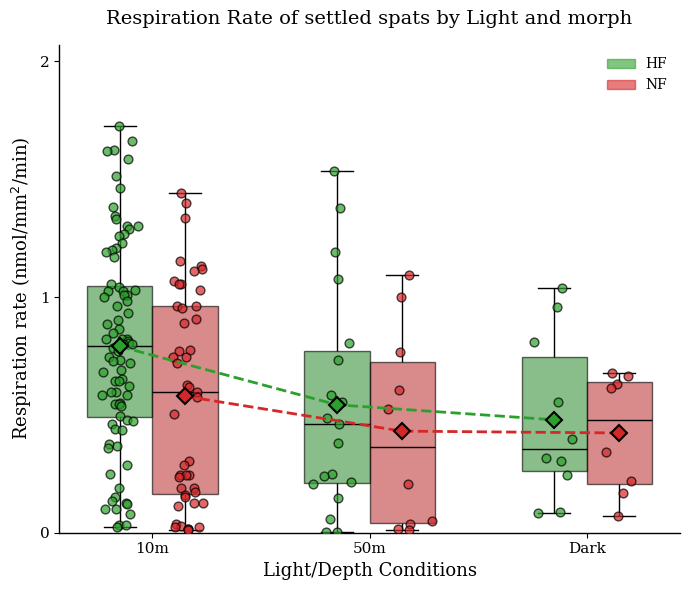

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "Light_Assay.csv"
df = pd.read_csv(filename)

# --- Handle 'morph' and 'color' columns consistently ---
# The prompt states 'color' contains HF/NF info, so we use that as the canonical 'morph' column.
if 'color' in df.columns:
    # Save the desired 'morph' data from 'color' before dropping anything
    desired_morph_data = df['color'].copy()
    # Drop the original 'color' column
    df = df.drop(columns=['color'])
    # If an old 'morph' column exists, drop it to prevent duplicates
    if 'morph' in df.columns:
        df = df.drop(columns=['morph'])
    # Add the desired 'morph' data as the canonical 'morph' column
    df['morph'] = desired_morph_data
# else: If 'color' column doesn't exist, assume 'morph' column is already correctly named and contains HF/NF.

# Rename 'OxyRate nmol/mm2/min' to 'OxyRate'
df = df.rename(columns={
    "OxyRate nmol/mm2/min": "OxyRate"
})

# --- NEW: Filter samples above 2.09 and print removed samples ---
removed_light_samples = df[df['OxyRate'] > 2.09]
if not removed_light_samples.empty:
    print("--- Light Samples Removed (OxyRate > 2.09) ---")
    for index, row in removed_light_samples.iterrows():
        print(f"Morph: {row['morph']}, SampleCode: {row['SampleCode']}, OxyRate: {row['OxyRate']:.2f}")
    print("--------------------------------------------------")
df = df[df['OxyRate'] <= 2.09]
# ----------------------------------------------------------------

# Clean and Order the LightDepth column
# Logic: High Light (10m) -> Low Light (50m) -> No Light (Dark)
df["LightDepth"] = df["LightDepth"].astype(str).str.strip()
light_order = ["10m", "50m", "Dark"]
df["LightDepth"] = pd.Categorical(df["LightDepth"], categories=light_order, ordered=True)

# Drop rows with unexpected LightDepth values
df = df[df["LightDepth"].isin(light_order)].copy()
df = df.reset_index(drop=True) # Ensure unique index after filtering

# ==========================================
# 2. STATISTICS (Two-Way ANOVA & Tukey's HSD)
# ==========================================
# Model: OxyRate depends on morph and LightDepth
model = ols("OxyRate ~ C(morph) + C(LightDepth) + C(morph):C(LightDepth)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Two-Way ANOVA Results ===")
print(anova_table)

# 2.1 Tukey's HSD Post-hoc Test
df['group'] = df['morph'].astype(str) + "_" + df['LightDepth'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df['OxyRate'], groups=df['group'], alpha=0.05)

print("\n=== Tukey's HSD Post-hoc Test Results ===")
print(tukey_result)

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

# ==========================================
# 4. PLOT CONSTRUCTION
# ==========================================
box_width = 0.6
offset = box_width / 4

x_positions = {
    "HF": -offset,
    "NF": +offset
}

# Variable to plot on X-axis
x_col = "LightDepth"
x_order = light_order

for morph in morph_order:
    sub = df[df["morph"] == morph]

    # A. Boxplots
    sns.boxplot(
        data=sub, x=x_col, y="OxyRate",
        order=x_order,
        width=box_width / 2,
        color=variant_colors[morph],
        showfliers=False, linewidth=1,
        boxprops=dict(edgecolor="black", alpha=0.6),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
        ax=ax,
        positions=np.arange(len(x_order)) + x_positions[morph]
    )

    # B. Jittered points
    for i, level in enumerate(x_order):
        y = sub[sub[x_col] == level]["OxyRate"]
        # Add random jitter to x
        x = np.random.normal(i + x_positions[morph], 0.04, size=len(y))

        ax.scatter(
            x, y,
            s=40, c=variant_colors[morph],
            edgecolors="black", linewidths=1,
            alpha=0.7, zorder=3
        )

    # C. Mean diamonds (changed from median)
    means = sub.groupby(x_col)["OxyRate"].mean().reindex(x_order)

    ax.plot(
        np.arange(len(x_order)) + x_positions[morph],
        means,
        marker="D", linestyle="--",
        markersize=8,
        markerfacecolor=variant_colors[morph],
        markeredgecolor="black",
        markeredgewidth=1.5,
        linewidth=2,
        color=variant_colors[morph],
        zorder=4
    )

# ==========================================
# 5. LABELS, LEGEND & ANNOTATION
# ==========================================
ax.set_ylabel("Respiration rate (nmol/mm$^2$/min)", fontsize=13)
ax.set_xlabel("Light/Depth Conditions", fontsize=13)
ax.set_title("Respiration Rate of settled spats by Light and morph", fontsize=14, pad=15)

# Custom Legend
legend_handles = []
for morph in morph_order:
    patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)
    legend_handles.append(patch)
ax.legend(handles=legend_handles, labels=morph_order, title=None, frameon=False, loc="upper right")

# Fix X-axis ticks
ax.set_xticks(np.arange(len(x_order)))
ax.set_xticklabels(x_order)

# Y-axis formatting
max_val = df["OxyRate"].max()
ax.set_ylim(0, max_val * 1.2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1)) # Adjusted tick frequency to 1

sns.despine(ax=ax)
fig.tight_layout()

# Save options   ---> remove # to get a downloadedble plot
plt.savefig("Respiration_Rate_by_Light.png", dpi=600)
#plt.savefig("Respiration_Rate_by_Light.pdf", dpi=600)
#plt.savefig("Respiration_Rate_by_Light.tiff", dpi=600)
#plt.savefig("Respiration_Rate_by_Light_transparent.svg", dpi=600, transparent=True)
#plt.savefig("Respiration_Rate_by_Light_white.svg", dpi=600, facecolor='white')
plt.show()

In [65]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

# df is already loaded and preprocessed by the previous cell (ZVpDdIqIZj6I)
# The 'PF' morph has been filtered out, and 'OxyRate' has been renamed.
# 'LightDepth' is already categorical and ordered.

# 1. Calculate descriptive statistics (N, Mean, Std Dev) grouped by 'morph' and 'LightDepth'
descriptive_stats_light = df.groupby(['morph', 'LightDepth'], observed=False)['OxyRate'].agg(
    N='count',
    Mean='mean',
    Std_Dev_Col='std'
).reset_index()
descriptive_stats_light = descriptive_stats_light.rename(columns={'Std_Dev_Col': 'Std Dev'})

# 2. Format the descriptive statistics table to 3 decimal places and print it
descriptive_stats_light_formatted = descriptive_stats_light.round(3)
print("\n=== Descriptive Statistics (Light Assay - HF, NF only) ===")
print(descriptive_stats_light_formatted.to_string(index=False))

# 3. Perform a Two-Way ANOVA
model_light = ols("OxyRate ~ C(morph) + C(LightDepth) + C(morph):C(LightDepth)", data=df).fit()
anova_table_light = sm.stats.anova_lm(model_light, typ=2)

# 4. Extract F-value, df, and P-value for main effects and interaction
anova_results_data = {
    'Source': ['C(morph)', 'C(LightDepth)', 'C(morph):C(LightDepth)']
}

# Safely get values, handling cases where a source might not be present (though for ANOVA it should be)
for stat in ['df', 'F', 'PR(>F)']:
    col_name = 'F-value' if stat == 'F' else ('P-value' if stat == 'PR(>F)' else stat)
    anova_results_data[col_name] = [
        anova_table_light.loc['C(morph)', stat] if 'C(morph)' in anova_table_light.index else np.nan,
        anova_table_light.loc['C(LightDepth)', stat] if 'C(LightDepth)' in anova_table_light.index else np.nan,
        anova_table_light.loc['C(morph):C(LightDepth)', stat] if 'C(morph):C(LightDepth)' in anova_table_light.index else np.nan
    ]

anova_results_df_light = pd.DataFrame(anova_results_data)

# 5. Format the ANOVA results table to 3 decimal places and print it
anova_results_df_light_formatted = anova_results_df_light.round(3)
print("\n=== Two-Way ANOVA Results (Light Assay - HF, NF only) ===")
print(anova_results_df_light_formatted.to_string(index=False))


=== Descriptive Statistics (Light Assay - HF, NF only) ===
morph LightDepth  N  Mean  Std Dev
   HF        10m 84 0.791    0.435
   HF        50m 19 0.543    0.465
   HF       Dark 10 0.479    0.347
   NF        10m 47 0.579    0.446
   NF        50m 10 0.431    0.423
   NF       Dark  8 0.423    0.251

=== Two-Way ANOVA Results (Light Assay - HF, NF only) ===
                Source  df  F-value  P-value
              C(morph) 1.0    7.090    0.008
         C(LightDepth) 2.0    4.751    0.010
C(morph):C(LightDepth) 2.0    0.347    0.707


Respiration_Rate for spats in pH

=== Two-Way ANOVA Results ===
                   sum_sq     df          F        PR(>F)
C(morph)         0.291032    1.0   1.456791  2.287928e-01
C(pH)           12.244425    2.0  30.645356  2.069359e-12
C(morph):C(pH)   3.988762    2.0   9.983077  7.201928e-05
Residual        42.152776  211.0        NaN           NaN

=== Tukey's HSD Post-hoc Test Results ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
HF_7.6 HF_7.8  -0.8537    0.0 -1.2038 -0.5036   True
HF_7.6 HF_8.2  -0.6219    0.0 -0.9024 -0.3413   True
HF_7.6 NF_7.6  -0.2575 0.4941 -0.6782  0.1633  False
HF_7.6 NF_7.8  -0.3875 0.0509 -0.7758  0.0009  False
HF_7.6 NF_8.2  -0.8334    0.0 -1.1403 -0.5265   True
HF_7.8 HF_8.2   0.2319  0.194 -0.0566  0.5204  False
HF_7.8 NF_7.6   0.5963 0.0011  0.1701  1.0224   True
HF_7.8 NF_7.8   0.4663 0.0102  0.0721  0.8604   True
HF_7.8 NF_8.2   0.0203    1.0 -0.2939  0.3345  False
H

/tmp/ipython-input-2009113946.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby("pH")["OxyRate"].mean().reindex(ph_order)
/tmp/ipython-input-2009113946.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = sub.groupby("pH")["OxyRate"].mean().reindex(ph_order)
/tmp/ipython-input-2009113946.py:145: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)


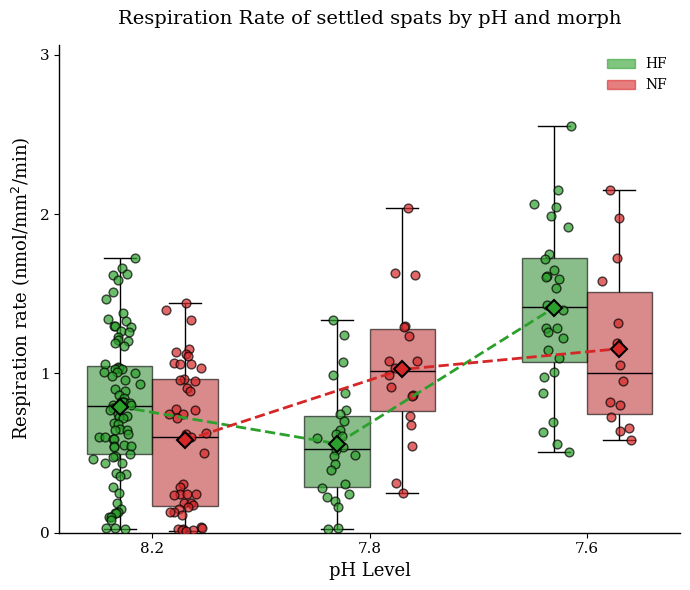

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "pH_Assay.csv"
df = pd.read_csv(filename)

# Normalize / rename the response column
df = df.rename(columns={"OxyRate nmol/mm2/min": "OxyRate"})

# Keep only HF / NF
target_morphs = ["HF", "NF"]
df = df[df["morph"].isin(target_morphs)].copy()

# --- MODIFIED: Specific Outlier Removal ---
# 1. Remove pH 8.2 NF Technical Errors (Plate D failures > 2.0)
# (Note: pH is likely float 8.2 here)
df = df[~((df['pH'] == 8.2) & (df['morph'] == 'NF') & (df['OxyRate'] > 2.0))]

# 2. Remove pH 7.8 HF Statistical Outliers (> 1.5)
# This removes both 2.36 AND 1.89 (which the previous >2.09 filter missed)
df = df[~((df['pH'] == 7.8) & (df['morph'] == 'HF') & (df['OxyRate'] > 1.5))]
# ------------------------------------------

# Ensure pH is clean and ordered
df["pH"] = df["pH"].astype(str).str.strip()
ph_order = ["8.2", "7.8", "7.6"]
df["pH"] = pd.Categorical(df["pH"], categories=ph_order, ordered=True)

# Optional: drop rows with unexpected pH values
df = df[df["pH"].isin(ph_order)].copy()

# ==========================================
# 2. STATISTICS (Two-Way ANOVA & Tukey's HSD)
# ==========================================
model = ols("OxyRate ~ C(morph) + C(pH) + C(morph):C(pH)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Two-Way ANOVA Results ===")
print(anova_table)

# 2.1 Tukey's HSD Post-hoc Test
df['group'] = df['morph'].astype(str) + "_" + df['pH'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df['OxyRate'], groups=df['group'], alpha=0.05)

print("\n=== Tukey's HSD Post-hoc Test Results ===")
print(tukey_result)

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

# ==========================================
# 4. PLOT CONSTRUCTION (MANUAL ALIGNMENT)
# ==========================================
box_width = 0.6
offset = box_width / 4

x_positions = {
    "HF": -offset,
    "NF": +offset
}

for morph in morph_order:
    sub = df[df["morph"] == morph]

    # A. Boxplots
    sns.boxplot(
        data=sub, x="pH", y="OxyRate",
        order=ph_order,
        width=box_width / 2,
        color=variant_colors[morph],
        showfliers=False, linewidth=1,
        boxprops=dict(edgecolor="black", alpha=0.6),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
        ax=ax,
        positions=np.arange(len(ph_order)) + x_positions[morph]
    )

    # B. Jittered points
    for i, ph in enumerate(ph_order):
        y = sub[sub["pH"] == ph]["OxyRate"]
        positions_for_jitter = np.arange(len(ph_order)) + x_positions[morph]
        x = np.random.normal(positions_for_jitter[i], 0.04, size=len(y))

        ax.scatter(
            x, y,
            s=40, c=variant_colors[morph],
            edgecolors="black", linewidths=1,
            alpha=0.7, zorder=3
        )

    # C. Mean diamonds
    means = sub.groupby("pH")["OxyRate"].mean().reindex(ph_order)

    ax.plot(
        np.arange(len(ph_order)) + x_positions[morph],
        means,
        marker="D", linestyle="--",
        markersize=8,
        markerfacecolor=variant_colors[morph],
        markeredgecolor="black",
        markeredgewidth=1.5,
        linewidth=2,
        color=variant_colors[morph],
        zorder=4
    )

# ==========================================
# 6. LABELS & TITLE
# ==========================================
ax.set_ylabel("Respiration rate (nmol/mm$^2$/min)", fontsize=13)
ax.set_xlabel("pH Level", fontsize=13)
ax.set_title("Respiration Rate of settled spats by pH and morph", fontsize=14, pad=15)

# Custom Legend
legend_handles = []
for morph in morph_order:
    patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)
    legend_handles.append(patch)
ax.legend(handles=legend_handles, labels=morph_order, title=None, frameon=False, loc="upper right")

# Y-axis formatting
max_val = df["OxyRate"].max()
ax.set_ylim(0, max_val * 1.2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

sns.despine(ax=ax)
fig.tight_layout()

plt.savefig("Respiration_Rate_by_pH.png", dpi=600)
#plt.savefig("Respiration_Rate_by_pH.pdf", dpi=600)
#plt.savefig("Respiration_Rate_by_pH.tiff", dpi=600)
#plt.savefig("Respiration_Rate_by_pH_transparent.svg", dpi=600, transparent=True)
#plt.savefig("Respiration_Rate_by_pH_white.svg", dpi=600, facecolor='white')

plt.show()

In [63]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Load the 'pH_Assay.csv' dataset
filename = "pH_Assay.csv"
df_ph = pd.read_csv(filename)

# 2. Rename the column 'OxyRate nmol/mm2/min' to 'OxyRate'
df_ph = df_ph.rename(columns={"OxyRate nmol/mm2/min": "OxyRate"})

# 3. Filter for target morphs (HF, NF) - already done in previous cells, but good to ensure
target_morphs = ["HF", "NF"]
df_ph = df_ph[df_ph["morph"].isin(target_morphs)].copy()

# 4. Apply specific outlier removals
removed_ph_samples_list = [] # Initialize a list to collect removed samples

# Remove pH 8.2 NF Technical Errors (OxyRate > 2.0)
condition_nf_ph82_outlier = (df_ph['pH'] == 8.2) & (df_ph['morph'] == 'NF') & (df_ph['OxyRate'] > 2.0)
removed_samples_nf_ph82 = df_ph[condition_nf_ph82_outlier]
if not removed_samples_nf_ph82.empty:
    removed_ph_samples_list.append(removed_samples_nf_ph82)
df_ph = df_ph[~condition_nf_ph82_outlier]

# Remove pH 7.8 HF Statistical Outliers (OxyRate > 1.5)
condition_hf_ph78_outlier = (df_ph['pH'] == 7.8) & (df_ph['morph'] == 'HF') & (df_ph['OxyRate'] > 1.5)
removed_samples_hf_ph78 = df_ph[condition_hf_ph78_outlier]
if not removed_samples_hf_ph78.empty:
    removed_ph_samples_list.append(removed_samples_hf_ph78)
df_ph = df_ph[~condition_hf_ph78_outlier]

# Concatenate all removed samples for printing, if any
removed_ph_samples = pd.DataFrame(columns=df_ph.columns) # Initialize with columns to preserve dtypes
if removed_ph_samples_list:
    removed_ph_samples = pd.concat(removed_ph_samples_list)

if not removed_ph_samples.empty:
    print("--- pH Samples Removed (Specific Outliers) ---")
    for index, row in removed_ph_samples.iterrows():
        print(f"Morph: {row['morph']}, pH: {row['pH']}, OxyRate: {row['OxyRate']:.2f}")
    print("--------------------------------------------------")

# 5. Clean and order the 'pH' column
df_ph["pH"] = df_ph["pH"].astype(str).str.strip()
ph_order = ["8.2", "7.8", "7.6"]
df_ph["pH"] = pd.Categorical(df_ph["pH"], categories=ph_order, ordered=True)
# Optional: drop rows with unexpected pH values (already handled by categorical type)
df_ph = df_ph[df_ph["pH"].isin(ph_order)].copy().reset_index(drop=True)

# 6. Calculate descriptive statistics (N, Mean, Std Dev) grouped by 'morph' and 'pH'
descriptive_stats_ph = df_ph.groupby(['morph', 'pH'], observed=False)['OxyRate'].agg(
    N='count',
    Mean='mean',
    Std_Dev_Col='std'
).reset_index()
descriptive_stats_ph = descriptive_stats_ph.rename(columns={'Std_Dev_Col': 'Std Dev'})

# 7. Format the descriptive statistics table to 3 decimal places and print it
descriptive_stats_ph_formatted = descriptive_stats_ph.round(3)
print("\n=== Descriptive Statistics (pH Assay) ===")
print(descriptive_stats_ph_formatted.to_string(index=False))

# 8. Perform a Two-Way ANOVA
model_ph = ols("OxyRate ~ C(morph) + C(pH) + C(morph):C(pH)", data=df_ph).fit()
anova_table_ph = sm.stats.anova_lm(model_ph, typ=2)

# 9. Extract F-value, df, and P-value for main effects and interaction
anova_results_data_ph = {
    'Source': ['C(morph)', 'C(pH)', 'C(morph):C(pH)']
}

for stat in ['df', 'F', 'PR(>F)']:
    col_name = 'F-value' if stat == 'F' else ('P-value' if stat == 'PR(>F)' else stat)
    anova_results_data_ph[col_name] = [
        anova_table_ph.loc['C(morph)', stat] if 'C(morph)' in anova_table_ph.index else np.nan,
        anova_table_ph.loc['C(pH)', stat] if 'C(pH)' in anova_table_ph.index else np.nan,
        anova_table_ph.loc['C(morph):C(pH)', stat] if 'C(morph):C(pH)' in anova_table_ph.index else np.nan
    ]

anova_results_df_ph = pd.DataFrame(anova_results_data_ph)

# 10. Format the ANOVA results table to 3 decimal places and print it
anova_results_df_ph_formatted = anova_results_df_ph.round(3)
print("\n=== Two-Way ANOVA Results (pH Assay) ===")
print(anova_results_df_ph_formatted.to_string(index=False))

--- pH Samples Removed (Specific Outliers) ---
Morph: NF, pH: 8.2, OxyRate: 5.27
Morph: NF, pH: 8.2, OxyRate: 4.21
Morph: NF, pH: 8.2, OxyRate: 3.01
Morph: NF, pH: 8.2, OxyRate: 2.62
Morph: NF, pH: 8.2, OxyRate: 2.41
Morph: NF, pH: 8.2, OxyRate: 2.10
Morph: HF, pH: 7.8, OxyRate: 2.36
Morph: HF, pH: 7.8, OxyRate: 1.89
--------------------------------------------------

=== Descriptive Statistics (pH Assay) ===
morph  pH  N  Mean  Std Dev
   HF 8.2 84 0.791    0.435
   HF 7.8 26 0.559    0.346
   HF 7.6 28 1.412    0.517
   NF 8.2 47 0.579    0.446
   NF 7.8 18 1.025    0.457
   NF 7.6 14 1.155    0.520

=== Two-Way ANOVA Results (pH Assay) ===
        Source  df  F-value  P-value
      C(morph) 1.0    1.457    0.229
         C(pH) 2.0   30.645    0.000
C(morph):C(pH) 2.0    9.983    0.000


Respiration_Rate for spats in Temp

--- Temperature Samples Removed (Specific Defect) ---
Morph: NF, SampleCode: plateD_NF_8.2_2, Temp: 23, OxyRate: 2.10
---------------------------------------------------
--- Temperature Samples Removed (Grouped 1.5 IQR) ---
Morph: HF, SampleCode: plate3_22a, Temp: 32, OxyRate: 0.90
Morph: NF, SampleCode: plateD_NF_8.2_7, Temp: 23, OxyRate: 5.27
Morph: NF, SampleCode: plateD_NF_8.2_7, Temp: 23, OxyRate: 4.21
Morph: NF, SampleCode: plateD_NF_8.2_3, Temp: 23, OxyRate: 3.01
Morph: NF, SampleCode: plateD_NF_8.2_2, Temp: 23, OxyRate: 2.62
Morph: NF, SampleCode: plateD_NF_8.2_3, Temp: 23, OxyRate: 2.41
Morph: NF, SampleCode: Plate3_24a, Temp: 32, OxyRate: 0.89
Morph: NF, SampleCode: plate3_24b, Temp: 32, OxyRate: 0.37
Morph: PF, SampleCode: med_Flu_polyp, Temp: 23, OxyRate: 2.87
Morph: PF, SampleCode: plate3_68c, Temp: 32, OxyRate: 0.13
-----------------------------------------------------------
=== Two-Way ANOVA Results ===
                     sum_sq     df          F        PR(>F)
C(morph)

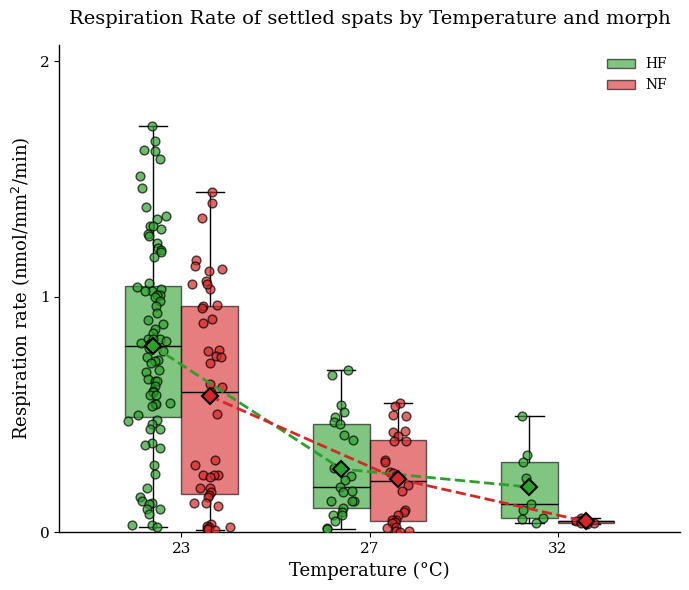

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "Temp_Assay.csv"
df = pd.read_csv(filename)

# Clean column names
df = df.rename(columns={"OxyRate nmol/mm2/min": "OxyRate"})
if 'color' in df.columns:
    df = df.rename(columns={"color": "morph"})

# --- NEW: Specific Defect Sample Removal ---
specific_point_to_remove = df[
    (df['SampleCode'] == 'plateD_NF_8.2_2') &
    (df['OxyRate'] == 2.098348468) # Using the precise value from Light_Assay.csv output
].copy()

if not specific_point_to_remove.empty:
    print("--- Temperature Samples Removed (Specific Defect) ---")
    for index, row in specific_point_to_remove.iterrows():
        print(f"Morph: {row['morph']}, SampleCode: {row['SampleCode']}, Temp: {row['temp']}, OxyRate: {row['OxyRate']:.2f}")
    print("---------------------------------------------------")
    # Remove the identified row(s) from the main DataFrame
    df = df.drop(specific_point_to_remove.index)
# ------------------------------------------

# --- DATA CLEANING (Existing) ---
# 1. Grouped 1.5 IQR Outlier Removal
# Initialize a list to store removed samples
removed_outliers_list = []

# Iterate through each unique combination of 'morph' and 'temp'
for (morph_group, temp_group), group_df in df.groupby(['morph', 'temp'], observed=False):
    Q1 = group_df['OxyRate'].quantile(0.25)
    Q3 = group_df['OxyRate'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers in the current group
    outliers = group_df[(group_df['OxyRate'] < lower_bound) | (group_df['OxyRate'] > upper_bound)]

    # Append outliers to the list
    if not outliers.empty:
        removed_outliers_list.append(outliers)

# Concatenate all removed outliers into a single DataFrame
removed_temp_samples_iqr = pd.DataFrame(columns=df.columns) # Initialize with columns to preserve dtypes
if removed_outliers_list:
    removed_temp_samples_iqr = pd.concat(removed_outliers_list)

# Filter the main DataFrame `df` to remove all rows that are present in `removed_temp_samples_iqr`
# We use `isin` on the index to efficiently remove rows.
df = df[~df.index.isin(removed_temp_samples_iqr.index)]

# Print removed samples if any
if not removed_temp_samples_iqr.empty:
    print("--- Temperature Samples Removed (Grouped 1.5 IQR) ---")
    for index, row in removed_temp_samples_iqr.iterrows():
        print(f"Morph: {row['morph']}, SampleCode: {row['SampleCode']}, Temp: {row['temp']}, OxyRate: {row['OxyRate']:.2f}")
    print("-----------------------------------------------------------")

# 2. Reset Index
df = df.reset_index(drop=True)

# 3. Ensure Temp is Ordered Categorical
temp_order = [23, 27, 32]
df["temp"] = pd.Categorical(df["temp"], categories=temp_order, ordered=True)

# ==========================================
# 2. STATISTICS (Two-Way ANOVA)
# ==========================================
model = ols("OxyRate ~ C(morph) + C(temp) + C(morph):C(temp)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Two-Way ANOVA Results ===")
print(anova_table)

# Post-hoc Test
df['group'] = df['morph'].astype(str) + "_" + df['temp'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df['OxyRate'], groups=df['group'], alpha=0.05)
print("\n=== Tukey HSD ===")
print(tukey_result)

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

# ==========================================
# 4. PLOT CONSTRUCTION (MANUAL ALIGNMENT)
# ==========================================
box_width = 0.6
offset = box_width / 4

x_positions = {
    "HF": -offset,
    "NF": +offset
}

for morph in morph_order:
    sub = df[df["morph"] == morph]

    # Prepare data for manual boxplot (list of arrays)
    plot_data = [sub[sub["temp"] == t]["OxyRate"].values for t in temp_order]

    positions = np.arange(len(temp_order)) + x_positions[morph]

    # A. Boxplots
    bp = ax.boxplot(
        plot_data,
        positions=positions,
        widths=box_width / 2,
        patch_artist=True,
        showfliers=False,
        zorder=2
    )

    # Style
    for patch in bp['boxes']:
        patch.set_facecolor(variant_colors[morph])
        patch.set_alpha(0.6)
        patch.set_edgecolor('black')
        patch.set_linewidth(1)
    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1)

    # B. Jittered points
    for i, t in enumerate(temp_order):
        y = sub[sub["temp"] == t]["OxyRate"]
        # Jitter X
        x = np.random.normal(positions[i], 0.04, size=len(y))

        ax.scatter(
            x, y,
            s=40, c=variant_colors[morph],
            edgecolors="black", linewidths=1,
            alpha=0.7, zorder=3
        )

    # C. Mean Diamonds (changed from median)
    means = sub.groupby("temp", observed=False)["OxyRate"].mean().reindex(temp_order)

    ax.plot(
        positions,
        means,
        marker="D", linestyle="--",
        markersize=8,
        markerfacecolor=variant_colors[morph],
        markeredgecolor="black",
        markeredgewidth=1.5,
        linewidth=2,
        color=variant_colors[morph],
        zorder=4
    )

# ==========================================
# 5. LABELS & LEGEND
# ==========================================
ax.set_ylabel("Respiration rate (nmol/mm$^2$/min)", fontsize=13)
ax.set_xlabel("Temperature (°C)", fontsize=13)
ax.set_title("Respiration Rate of settled spats by Temperature and morph", fontsize=14, pad=15)

# Fix X-axis
ax.set_xticks(np.arange(len(temp_order)))
ax.set_xticklabels(temp_order)

# Legend
legend_handles = []
for morph in morph_order:
    patch = mpatches.Patch(facecolor=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)
    legend_handles.append(patch)
ax.legend(handles=legend_handles, labels=morph_order, title=None, frameon=False, loc="upper right")

# Y-axis scaling
max_val = df["OxyRate"].max()
ax.set_ylim(0, max_val * 1.2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

sns.despine(ax=ax)
fig.tight_layout()

# Save   ---> remove # to get a downloadedble plot
plt.savefig("Respiration_Rate_by_Temp.png", dpi=600)
#plt.savefig("Respiration_Rate_by_Temp.pdf", dpi=600)
#plt.savefig("Respiration_Rate_by_Temp.tiff", dpi=600)
#plt.savefig("Respiration_Rate_by_Temp_transparent.svg", dpi=600, transparent=True)
#plt.savefig("Respiration_Rate_by_Temp_white.svg", dpi=600, facecolor='white')

plt.show()

--- Temperature Samples Removed (Specific Defect) ---
Morph: NF, SampleCode: plateD_NF_8.2_2, Temp: 23, OxyRate: 2.10
---------------------------------------------------
--- Temperature Samples Removed (Grouped 1.5 IQR) ---
Morph: HF, SampleCode: plate3_22a, Temp: 32, OxyRate: 0.90
Morph: NF, SampleCode: plateD_NF_8.2_7, Temp: 23, OxyRate: 5.27
Morph: NF, SampleCode: plateD_NF_8.2_7, Temp: 23, OxyRate: 4.21
Morph: NF, SampleCode: plateD_NF_8.2_3, Temp: 23, OxyRate: 3.01
Morph: NF, SampleCode: plateD_NF_8.2_2, Temp: 23, OxyRate: 2.62
Morph: NF, SampleCode: plateD_NF_8.2_3, Temp: 23, OxyRate: 2.41
Morph: NF, SampleCode: Plate3_24a, Temp: 32, OxyRate: 0.89
Morph: NF, SampleCode: plate3_24b, Temp: 32, OxyRate: 0.37
Morph: PF, SampleCode: med_Flu_polyp, Temp: 23, OxyRate: 2.87
Morph: PF, SampleCode: plate3_68c, Temp: 32, OxyRate: 0.13
-----------------------------------------------------------
=== Two-Way ANOVA Results ===
                     sum_sq     df          F        PR(>F)
C(morph)

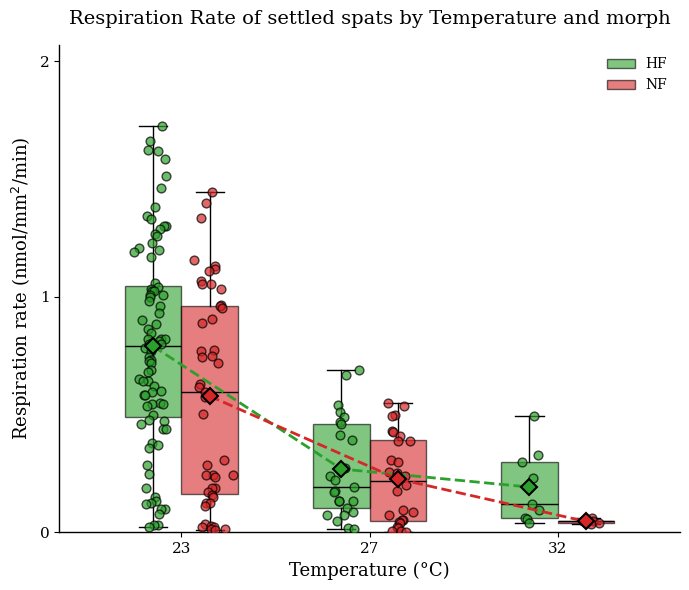

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "Temp_Assay.csv"
df = pd.read_csv(filename)

# Clean column names
df = df.rename(columns={"OxyRate nmol/mm2/min": "OxyRate"})
if 'color' in df.columns:
    df = df.rename(columns={"color": "morph"})

# --- NEW: Specific Defect Sample Removal ---
specific_point_to_remove = df[
    (df['SampleCode'] == 'plateD_NF_8.2_2') &
    (df['OxyRate'] == 2.098348468) # Using the precise value from Light_Assay.csv output
].copy()

if not specific_point_to_remove.empty:
    print("--- Temperature Samples Removed (Specific Defect) ---")
    for index, row in specific_point_to_remove.iterrows():
        print(f"Morph: {row['morph']}, SampleCode: {row['SampleCode']}, Temp: {row['temp']}, OxyRate: {row['OxyRate']:.2f}")
    print("---------------------------------------------------")
    # Remove the identified row(s) from the main DataFrame
    df = df.drop(specific_point_to_remove.index)
# ------------------------------------------

# --- DATA CLEANING (Existing) ---
# 1. Grouped 1.5 IQR Outlier Removal
# Initialize a list to store removed samples
removed_outliers_list = []

# Iterate through each unique combination of 'morph' and 'temp'
for (morph_group, temp_group), group_df in df.groupby(['morph', 'temp'], observed=False):
    Q1 = group_df['OxyRate'].quantile(0.25)
    Q3 = group_df['OxyRate'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers in the current group
    outliers = group_df[(group_df['OxyRate'] < lower_bound) | (group_df['OxyRate'] > upper_bound)]

    # Append outliers to the list
    if not outliers.empty:
        removed_outliers_list.append(outliers)

# Concatenate all removed outliers into a single DataFrame
removed_temp_samples_iqr = pd.DataFrame(columns=df.columns) # Initialize with columns to preserve dtypes
if removed_outliers_list:
    removed_temp_samples_iqr = pd.concat(removed_outliers_list)

# Filter the main DataFrame `df` to remove all rows that are present in `removed_temp_samples_iqr`
# We use `isin` on the index to efficiently remove rows.
df = df[~df.index.isin(removed_temp_samples_iqr.index)]

# Print removed samples if any
if not removed_temp_samples_iqr.empty:
    print("--- Temperature Samples Removed (Grouped 1.5 IQR) ---")
    for index, row in removed_temp_samples_iqr.iterrows():
        print(f"Morph: {row['morph']}, SampleCode: {row['SampleCode']}, Temp: {row['temp']}, OxyRate: {row['OxyRate']:.2f}")
    print("-----------------------------------------------------------")

# --- NEW: Filter out 'PF' morph ---
target_morphs_temp = ['HF', 'NF']
df = df[df['morph'].isin(target_morphs_temp)].copy()
# ----------------------------------

# 2. Reset Index
df = df.reset_index(drop=True)

# 3. Ensure Temp is Ordered Categorical
temp_order = [23, 27, 32]
df["temp"] = pd.Categorical(df["temp"], categories=temp_order, ordered=True)

# ==========================================
# 2. STATISTICS (Two-Way ANOVA)
# ==========================================
model = ols("OxyRate ~ C(morph) + C(temp) + C(morph):C(temp)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Two-Way ANOVA Results ===")
print(anova_table)

# Post-hoc Test
df['group'] = df['morph'].astype(str) + "_" + df['temp'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df['OxyRate'], groups=df['group'], alpha=0.05)
print("\n=== Tukey HSD ===")
print(tukey_result)

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

# ==========================================
# 4. PLOT CONSTRUCTION (MANUAL ALIGNMENT)
# ==========================================
box_width = 0.6
offset = box_width / 4

x_positions = {
    "HF": -offset,
    "NF": +offset
}

for morph in morph_order:
    sub = df[df["morph"] == morph]

    # Prepare data for manual boxplot (list of arrays)
    plot_data = [sub[sub["temp"] == t]["OxyRate"].values for t in temp_order]

    positions = np.arange(len(temp_order)) + x_positions[morph]

    # A. Boxplots
    bp = ax.boxplot(
        plot_data,
        positions=positions,
        widths=box_width / 2,
        patch_artist=True,
        showfliers=False,
        zorder=2
    )

    # Style
    for patch in bp['boxes']:
        patch.set_facecolor(variant_colors[morph])
        patch.set_alpha(0.6)
        patch.set_edgecolor('black')
        patch.set_linewidth(1)
    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1)

    # B. Jittered points
    for i, t in enumerate(temp_order):
        y = sub[sub["temp"] == t]["OxyRate"]
        # Jitter X
        x = np.random.normal(positions[i], 0.04, size=len(y))

        ax.scatter(
            x, y,
            s=40, c=variant_colors[morph],
            edgecolors="black", linewidths=1,
            alpha=0.7, zorder=3
        )

    # C. Mean Diamonds (changed from median)
    means = sub.groupby("temp", observed=False)["OxyRate"].mean().reindex(temp_order)

    ax.plot(
        positions,
        means,
        marker="D", linestyle="--",
        markersize=8,
        markerfacecolor=variant_colors[morph],
        markeredgecolor="black",
        markeredgewidth=1.5,
        linewidth=2,
        color=variant_colors[morph],
        zorder=4
    )

# ==========================================
# 5. LABELS & LEGEND
# ==========================================
ax.set_ylabel("Respiration rate (nmol/mm$^2$/min)", fontsize=13)
ax.set_xlabel("Temperature (°C)", fontsize=13)
ax.set_title("Respiration Rate of settled spats by Temperature and morph", fontsize=14, pad=15)

# Fix X-axis
ax.set_xticks(np.arange(len(temp_order)))
ax.set_xticklabels(temp_order)

# Legend
legend_handles = []
for morph in morph_order:
    patch = mpatches.Patch(facecolor=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)
    legend_handles.append(patch)
ax.legend(handles=legend_handles, labels=morph_order, title=None, frameon=False, loc="upper right")

# Y-axis scaling
max_val = df["OxyRate"].max()
ax.set_ylim(0, max_val * 1.2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

sns.despine(ax=ax)
fig.tight_layout()

# Save   ---> remove # to get a downloadedble plot
plt.savefig("Respiration_Rate_by_Temp.png", dpi=600)
#plt.savefig("Respiration_Rate_by_Temp.pdf", dpi=600)
#plt.savefig("Respiration_Rate_by_Temp.tiff", dpi=600)
#plt.savefig("Respiration_Rate_by_Temp_transparent.svg", dpi=600, transparent=True)
#plt.savefig("Respiration_Rate_by_Temp_white.svg", dpi=600, facecolor='white')

plt.show()